In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("cleaned_dataset.csv")

In [4]:
df

,Date,Food Item,Quantity Donated,Quantity Requested,Expiration Date,Seasonality,Holidays,Market Prices,Disaster Events,Recipient Preferences,...,Food Waste Rate,Distance Traveled (km),Transportation Mode,Storage Duration (days),Energy Used in Storage (kWh),Carbon Footprint,Fuel Type,Logistics Cost,Packaging Type,Refrigeration Required
0,1126,3,1.743647,0.008241,1309,-0.217808,-1.087845,-0.207863,1.922821,1.718779,...,0.053643,1.000423,2,1.347030,0.828260,1.085385,1,1.527415,3,-0.596601
1,1459,5,0.003221,-0.480422,1553,-0.272135,0.919249,-1.360160,1.922821,1.718779,...,0.352994,1.606908,1,0.364281,-0.021471,1.020734,1,1.889967,3,-0.596601
2,860,1,1.818024,1.742650,1112,-0.217808,0.919249,-0.002265,-0.407942,0.218121,...,-0.187317,-0.269210,3,1.715560,0.546732,0.590351,0,-0.001418,1,-0.596601
3,1294,3,-1.819020,-1.671107,1598,-0.360425,0.919249,-0.420316,-0.407942,1.343614,...,0.544058,-1.278498,1,0.241437,-0.632946,0.000000,1,-1.251428,0,-0.596601
4,1130,6,-1.759518,-1.292565,1245,-0.321825,0.919249,1.025198,-0.407942,-0.907373,...,3.274009,-0.353682,1,-1.601218,-1.068104,-0.724626,1,-0.779452,2,-0.596601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1401,6,1.699021,2.231312,1553,-0.336377,0.919249,-1.484390,-0.407942,-0.157044,...,4.837954,1.048890,4,-1.724061,-1.091263,0.000000,0,0.564297,1,-0.596601
19996,601,1,-0.718238,-0.432244,923,-0.454627,-1.087845,-0.208292,0.757440,-0.157044,...,-1.060552,0.219876,3,1.715560,3.957795,1.119575,0,0.705790,2,1.676163
19997,342,3,1.587455,0.008241,374,0.156209,0.919249,-0.709053,-0.407942,0.968450,...,-0.407924,0.358229,1,0.364281,-0.374996,0.026523,1,0.379223,3,-0.596601
19998,1797,5,-0.450480,-0.081232,1970,-0.067013,0.919249,1.323525,-0.407942,0.218121,...,0.780215,-1.197990,1,1.101342,-0.292632,-1.154801,1,-0.970529,2,-0.596601


# **Feature Selection :**

## Correlation Matrix

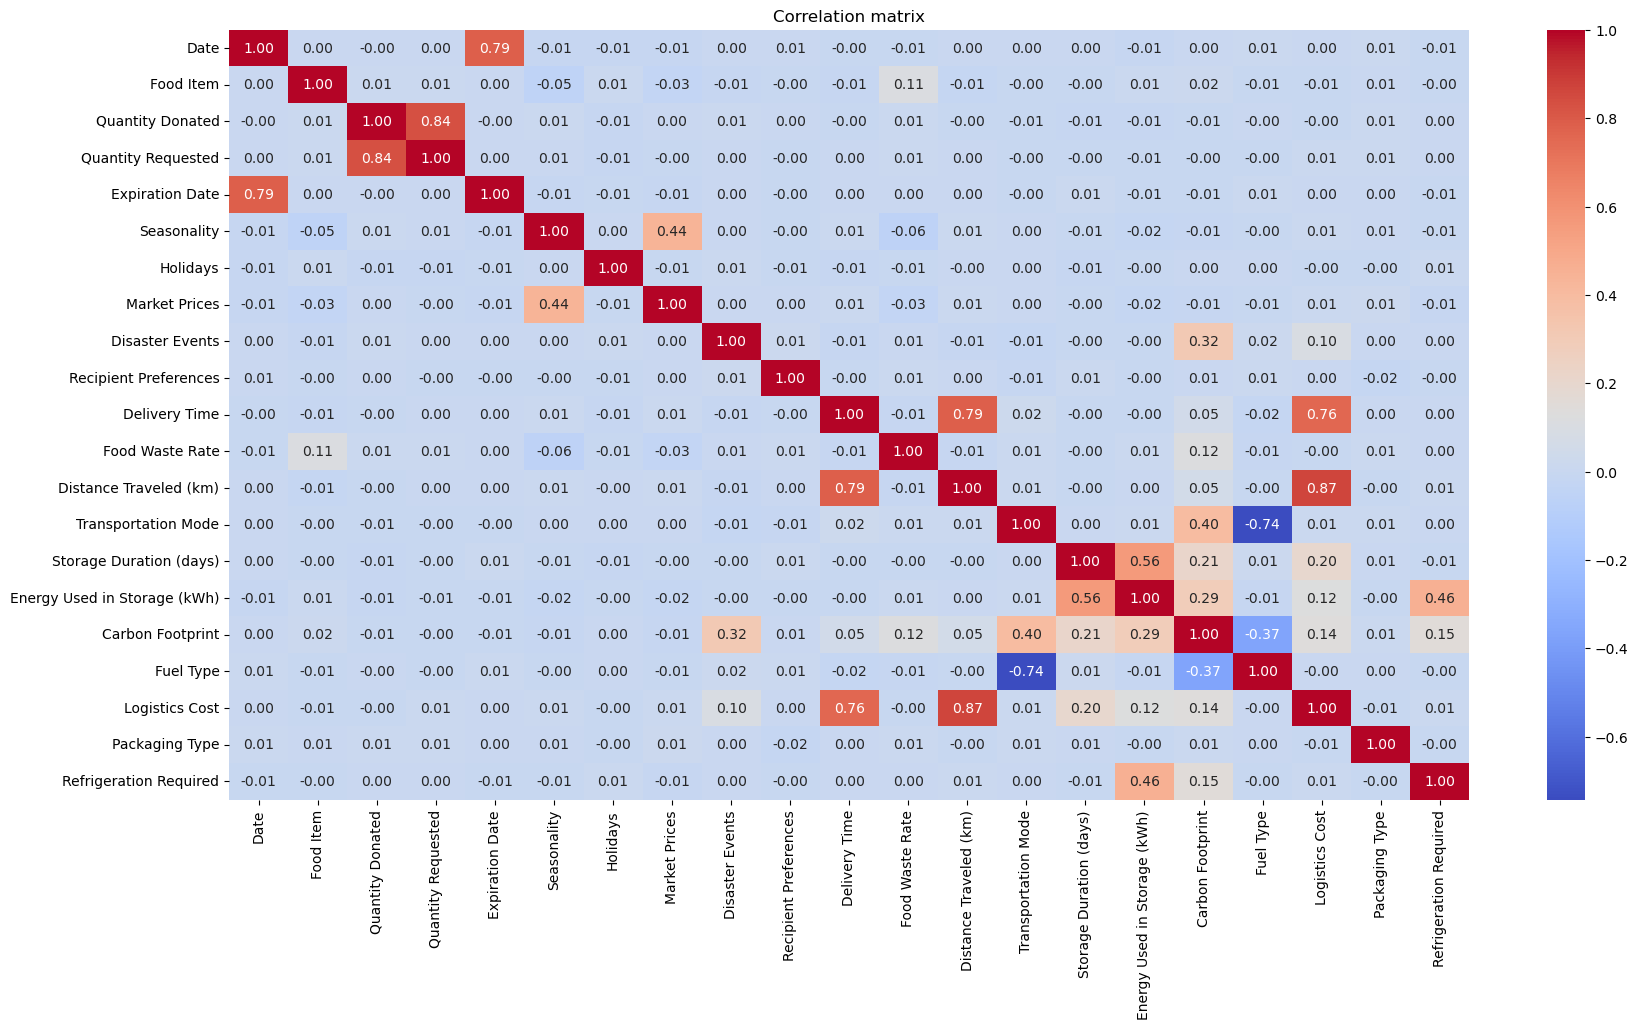

In [10]:
plt.figure(figsize=(20, 10))
corr_matrix = df.corr()  
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation matrix')
plt.show()

In [54]:
target = 'Carbon Footprint'
if target in df.columns:
    corr_matrix = df.corr()  
    print("\nCorrelation with the target before filtering :")
    print(corr_matrix[target].abs())  

    # Feature selection based on correlation
    correlation_threshold = 0.2  
    target_corr = corr_matrix[target].abs()
    selected_features = target_corr[target_corr > correlation_threshold].index.tolist()
    
    if target in selected_features:
        selected_features.remove(target)

    print(f"\nSelected features correlated with {target} (|corr| > {correlation_threshold}) : \n{selected_features}")


Correlation with the target before filtering :
Date                            0.000088
Food Item                       0.016348
Quantity Donated                0.005652
Quantity Requested              0.001251
Expiration Date                 0.007245
Seasonality                     0.011218
Holidays                        0.001278
Market Prices                   0.009534
Disaster Events                 0.317830
Recipient Preferences           0.005444
Delivery Time                   0.049867
Food Waste Rate                 0.116039
Distance Traveled (km)          0.054154
Transportation Mode             0.397635
Storage Duration (days)         0.211655
Energy Used in Storage (kWh)    0.291699
Carbon Footprint                1.000000
Fuel Type                       0.367046
Logistics Cost                  0.138301
Packaging Type                  0.009317
Refrigeration Required          0.153141
Name: Carbon Footprint, dtype: float64

Selected features correlated with Carbon Footprint 

In [56]:
df_selected = df[selected_features]
print(df_selected.head())

   Disaster Events  Transportation Mode  Storage Duration (days)  \
0         1.922821                    2                 1.347030   
1         1.922821                    1                 0.364281   
2        -0.407942                    3                 1.715560   
3        -0.407942                    1                 0.241437   
4        -0.407942                    1                -1.601218   

   Energy Used in Storage (kWh)  Fuel Type  
0                      0.828260          1  
1                     -0.021471          1  
2                      0.546732          0  
3                     -0.632946          1  
4                     -1.068104          1  


In [58]:
X = df_selected 
y = df[target]

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## KNN MODEL :

In [90]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import time


def train_knn_model(X_train, y_train, cv=5):
    """
    Train a K-Nearest Neighbors Regressor using GridSearchCV.
    
    Parameters:
        X_train (DataFrame): Training features.
        y_train (Series): Target variable.
        cv (int): Number of cross-validation folds.
    
    Returns:
        GridSearchCV object: Fitted KNN grid search model.
    """
    knn = KNeighborsRegressor()
    param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
    
    grid_search = GridSearchCV(
        estimator=knn,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )
    
    print("🔍 Starting GridSearchCV for KNN...")
    start = time.time()
    grid_search.fit(X_train, y_train)
    print(f"✅ GridSearch complete in {time.time() - start:.2f} seconds")
    print(f"📌 Best k: {grid_search.best_params_['n_neighbors']}")
    
    return grid_search


def evaluate_model(model, X_test, y_test):
    """
    Evaluate a regression model and print performance metrics.
    
    Parameters:
        model: Trained regression model.
        X_test (DataFrame): Test features.
        y_test (Series): True target values.
    """
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Evaluation:")
    print(f"• MSE  : {mse:.4f}")
    print(f"• RMSE : {rmse:.4f}")
    print(f"• R²   : {r2:.4f}")

    return y_pred, mse, rmse, r2


# --- Run Everything ---
knn_grid = train_knn_model(X_train, y_train)
best_knn = knn_grid.best_estimator_
y_pred_knn, knn_mse, knn_rmse, knn_r2 = evaluate_model(best_knn, X_test, y_test)


🔍 Starting GridSearchCV for KNN...
✅ GridSearch complete in 0.16 seconds
📌 Best k: 11

📊 Model Evaluation:
• MSE  : 0.4354
• RMSE : 0.6598
• R²   : 0.5495


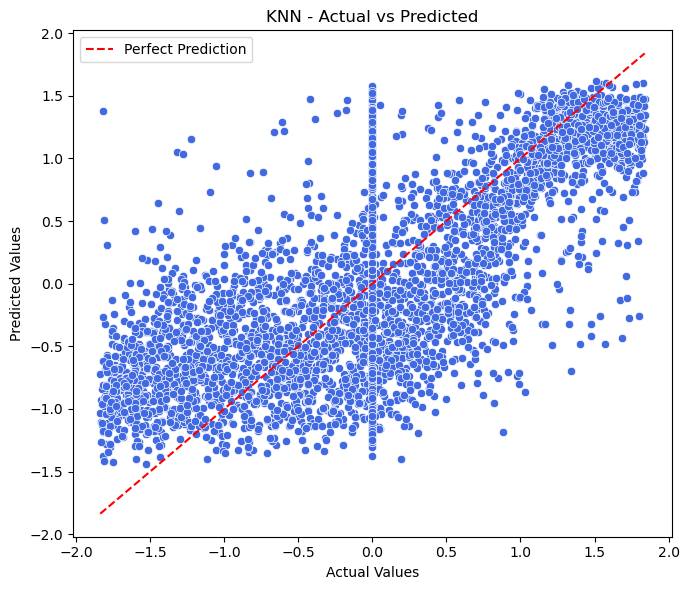

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_knn, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('KNN - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()


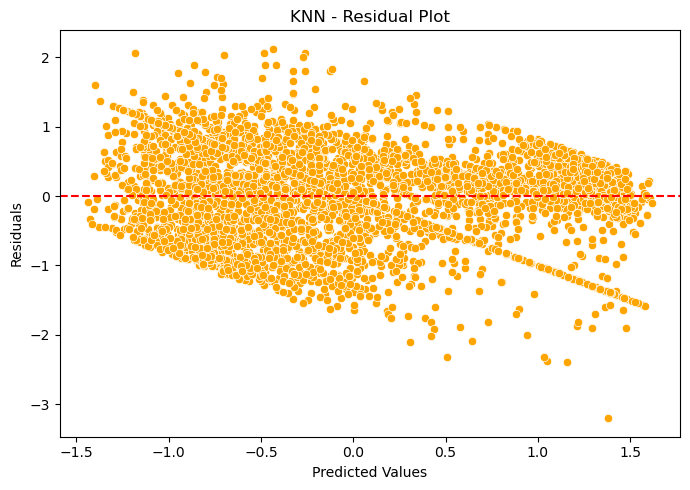

In [94]:
residuals = y_test - y_pred_knn

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred_knn, y=residuals, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('KNN - Residual Plot')
plt.tight_layout()
plt.show()


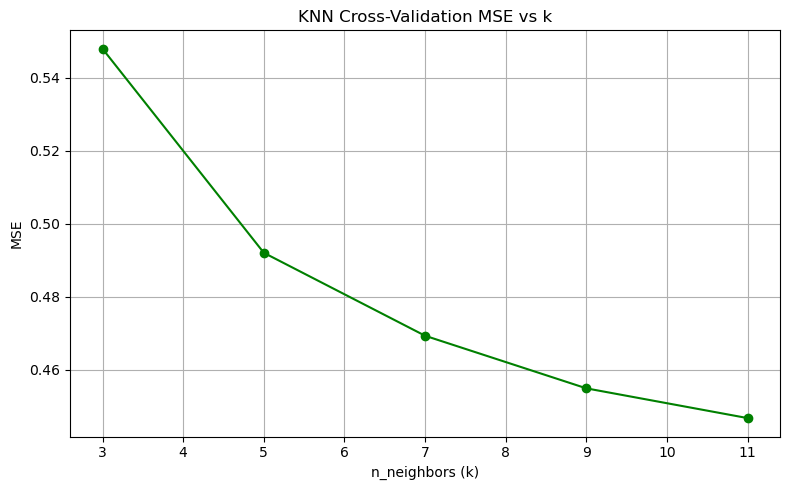

In [96]:
results = pd.DataFrame(knn_grid.cv_results_)
plt.figure(figsize=(8, 5))
plt.plot(knn_params['n_neighbors'], -results['mean_test_score'], marker='o', color='green')
plt.xlabel('n_neighbors (k)')
plt.ylabel('MSE')
plt.title('KNN Cross-Validation MSE vs k')
plt.grid(True)
plt.tight_layout()
plt.show()


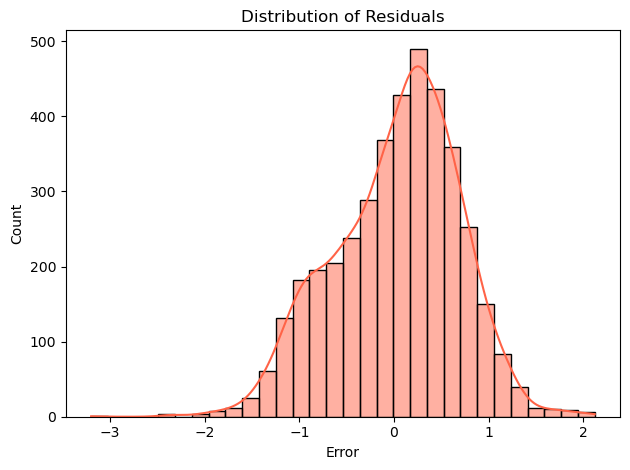

In [72]:
sns.histplot(residuals, kde=True, color='tomato', bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Error')
plt.tight_layout()
plt.show()

## SVR Model :

In [98]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import time


def train_svr_model(X_train, y_train, cv=5):
    """
    Trains an SVR model using GridSearchCV with specified hyperparameters.
    
    Parameters:
        X_train (DataFrame): Training feature set.
        y_train (Series): Target values.
        cv (int): Number of cross-validation folds.
    
    Returns:
        GridSearchCV: Fitted GridSearchCV object.
    """
    svr = SVR()
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    }
    
    grid_search = GridSearchCV(
        estimator=svr,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )
    
    print("🔍 Starting GridSearchCV for SVR...")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    print(f"✅ GridSearch complete in {elapsed:.2f} seconds")
    print(f"📌 Best parameters: {grid_search.best_params_}")
    
    return grid_search


def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluates a regression model and prints performance metrics.
    
    Parameters:
        model: Trained model with a .predict() method.
        X_test (DataFrame): Features for testing.
        y_test (Series): True values.
        model_name (str): Optional name of the model for display.
    
    Returns:
        tuple: (predictions, MSE, RMSE, R² score)
    """
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 {model_name} Evaluation Metrics:")
    print(f"• MSE  : {mse:.4f}")
    print(f"• RMSE : {rmse:.4f}")
    print(f"• R²   : {r2:.4f}")

    return y_pred, mse, rmse, r2


# --- Usage ---
svr_grid = train_svr_model(X_train, y_train)
best_svr = svr_grid.best_estimator_
y_pred_svr, svm_mse, svm_rmse, svm_r2 = evaluate_model(best_svr, X_test, y_test, model_name="SVR")


🔍 Starting GridSearchCV for SVR...
✅ GridSearch complete in 36.29 seconds
📌 Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

📊 SVR Evaluation Metrics:
• MSE  : 0.4144
• RMSE : 0.6437
• R²   : 0.5712


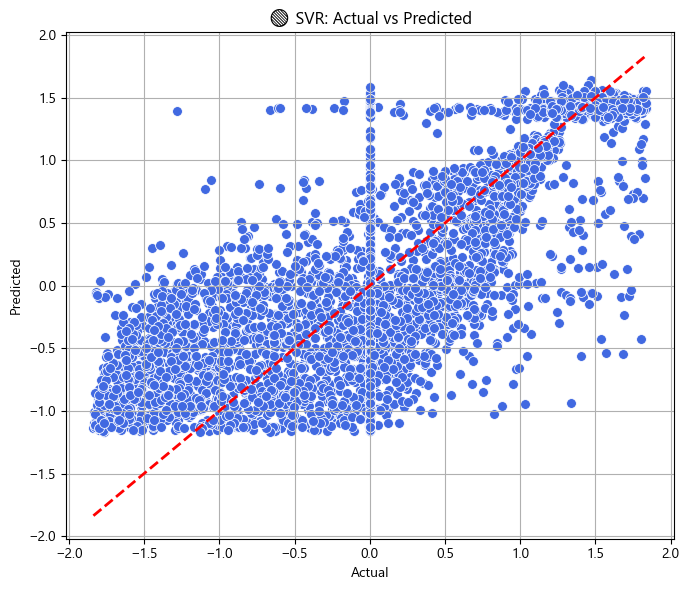

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm
prop = fm.FontProperties(fname="/path/to/NotoColorEmoji.ttf")

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_svr, color='royalblue', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('🔵 SVR: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


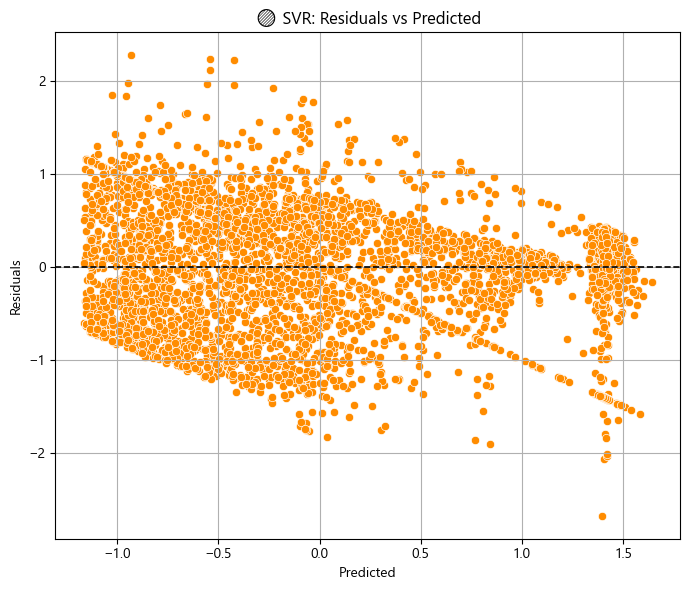

In [120]:
residuals = y_test - y_pred_svr

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_pred_svr, y=residuals, color='darkorange')
plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('🟠 SVR: Residuals vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


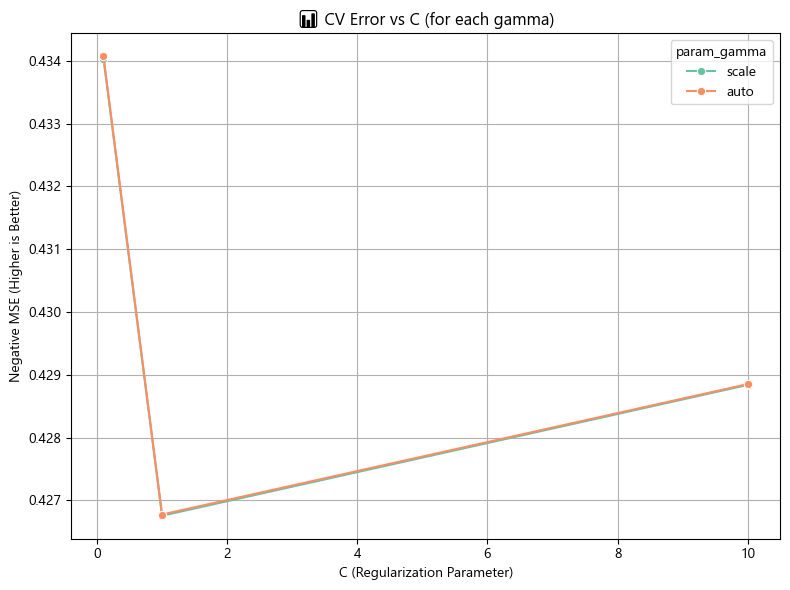

In [122]:
results = pd.DataFrame(svr_grid.cv_results_)
plt.figure(figsize=(8, 6))
sns.lineplot(data=results, x='param_C', y=-results['mean_test_score'], marker='o', hue='param_gamma', palette='Set2')
plt.title('📊 CV Error vs C (for each gamma)')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Negative MSE (Higher is Better)')
plt.grid(True)
plt.tight_layout()
plt.show()


## DECISION TREE MODEL :

In [146]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the model with a fixed random state for reproducibility
dt_model = DecisionTreeRegressor(random_state=42)

# Define a well-structured parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the model on training data
grid_search.fit(X_train, y_train)

# Extract the best estimator
best_dt_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred_dt = best_dt_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

# Display the results
print("\n🌳 Decision Tree Performance:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits

🌳 Decision Tree Performance:
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
MSE  : 0.4407
RMSE : 0.6638
R²   : 0.5440


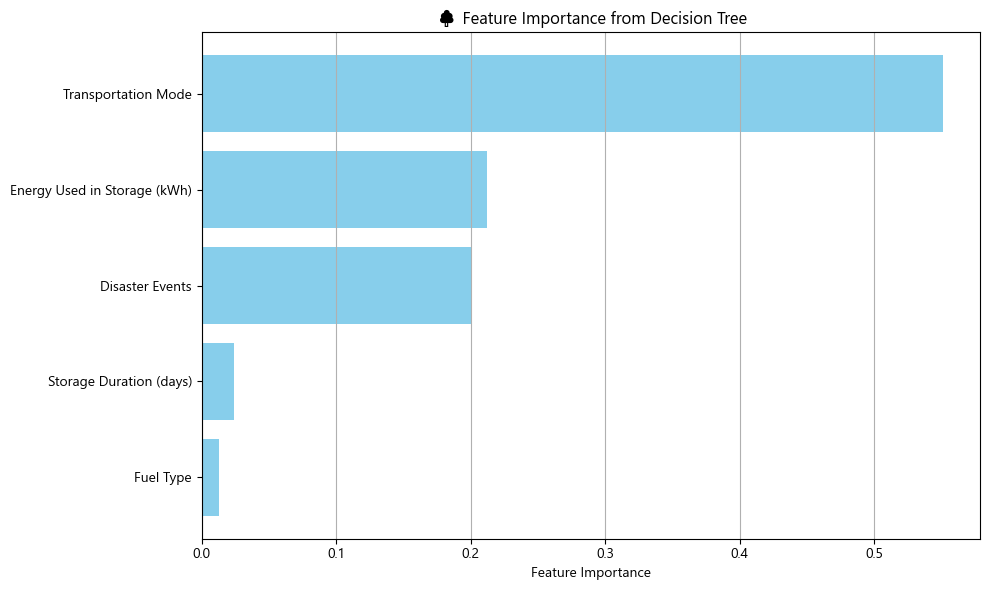

In [154]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
importances = best_dt_model.feature_importances_
feature_names = selected_features


# Create DataFrame for easy plotting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('🌳 Feature Importance from Decision Tree')
plt.gca().invert_yaxis()  # Highest importance on top
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


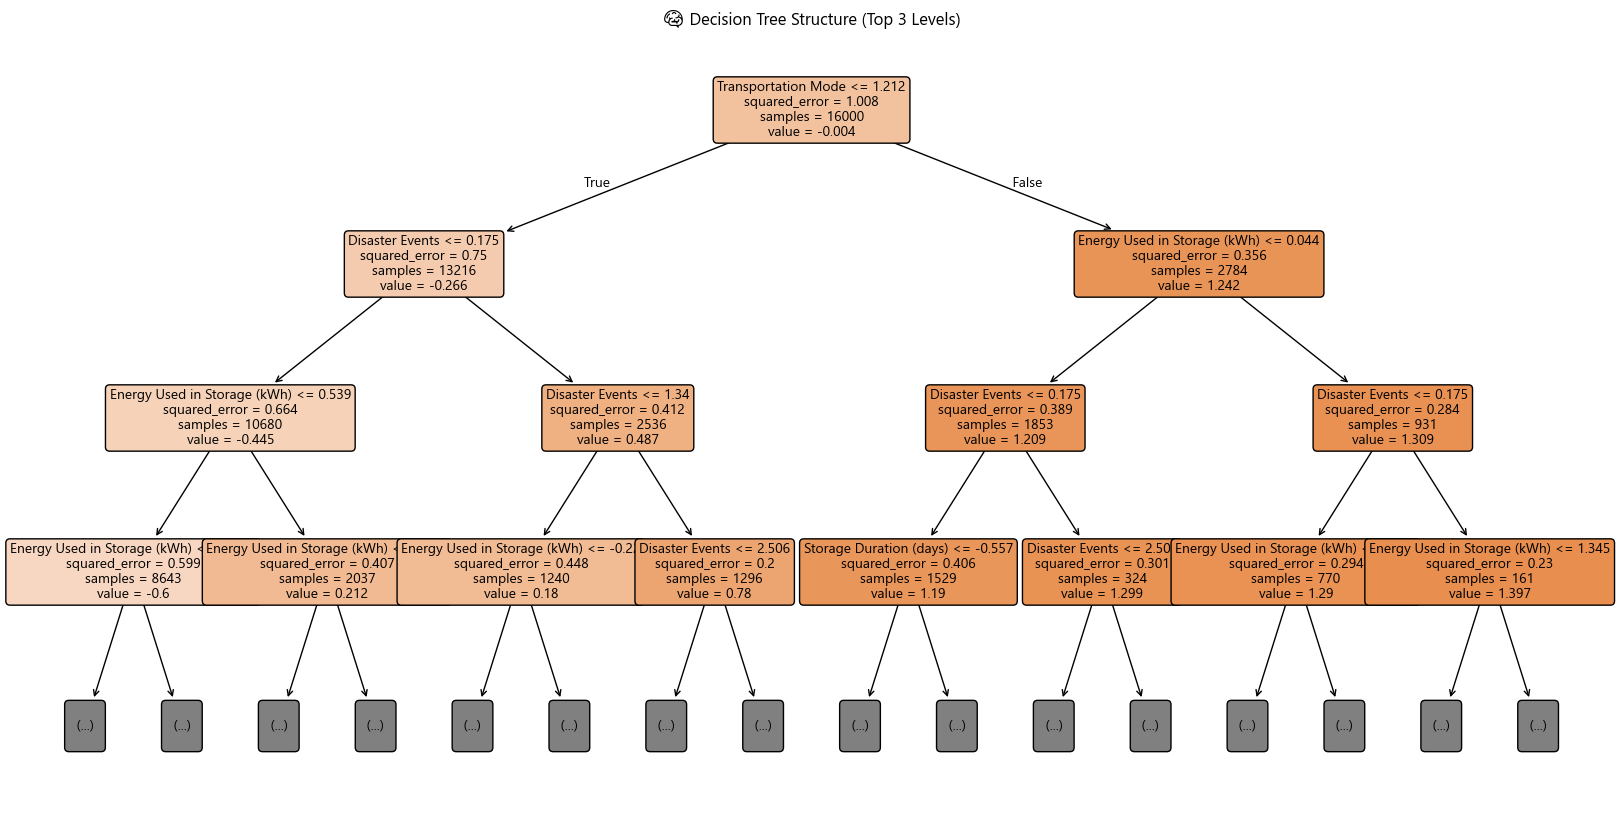

In [158]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best_dt_model, 
          feature_names=selected_features, 
          filled=True, 
          rounded=True, 
          max_depth=3,  # Change or remove for full tree
          fontsize=10)
plt.title("🧠 Decision Tree Structure (Top 3 Levels)")
plt.show()


In [160]:
import pandas as pd

# Assuming you already have these variables from each model:
# knn_rmse, knn_r2
# svm_rmse, svm_r2
# dt_rmse, dt_r2

results_df = pd.DataFrame({
    'Model': ['KNN', 'SVR', 'Decision Tree'],
    'RMSE': [knn_rmse, svm_rmse, dt_rmse],
    'R²': [knn_r2, svm_r2, dt_r2]
})

print(results_df)


           Model      RMSE        R²
0            KNN  0.659838  0.549473
1            SVR  0.643706  0.571232
2  Decision Tree  0.663841  0.543990


C:\Users\user\AppData\Local\Temp\ipykernel_3244\2199878076.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='RMSE', palette='coolwarm')
C:\Users\user\AppData\Local\Temp\ipykernel_3244\2199878076.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R²', palette='viridis')


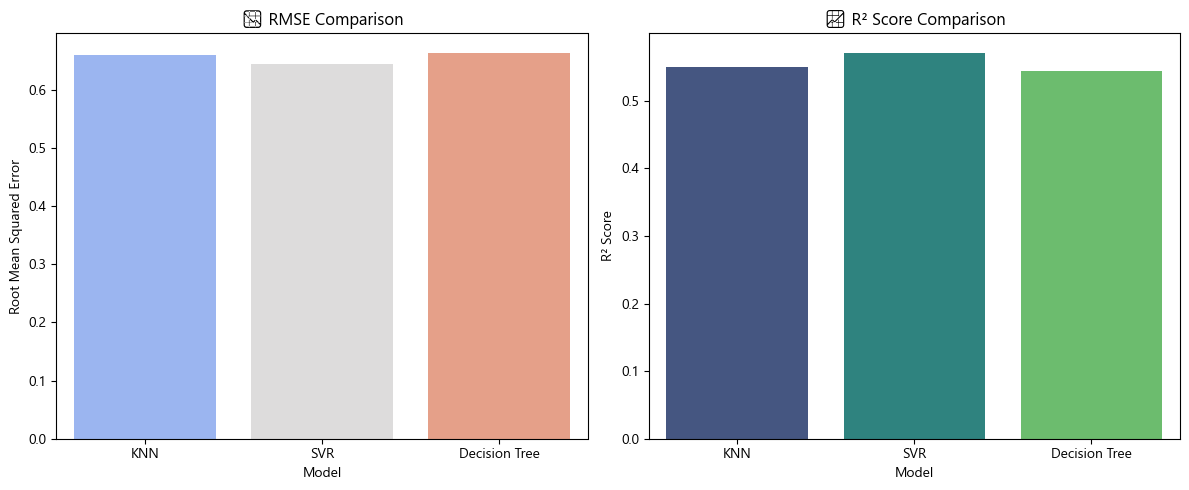

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# RMSE Plot
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='Model', y='RMSE', palette='coolwarm')
plt.title('📉 RMSE Comparison')
plt.ylabel('Root Mean Squared Error')

# R² Plot
plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x='Model', y='R²', palette='viridis')
plt.title('📈 R² Score Comparison')
plt.ylabel('R² Score')

plt.tight_layout()
plt.show()


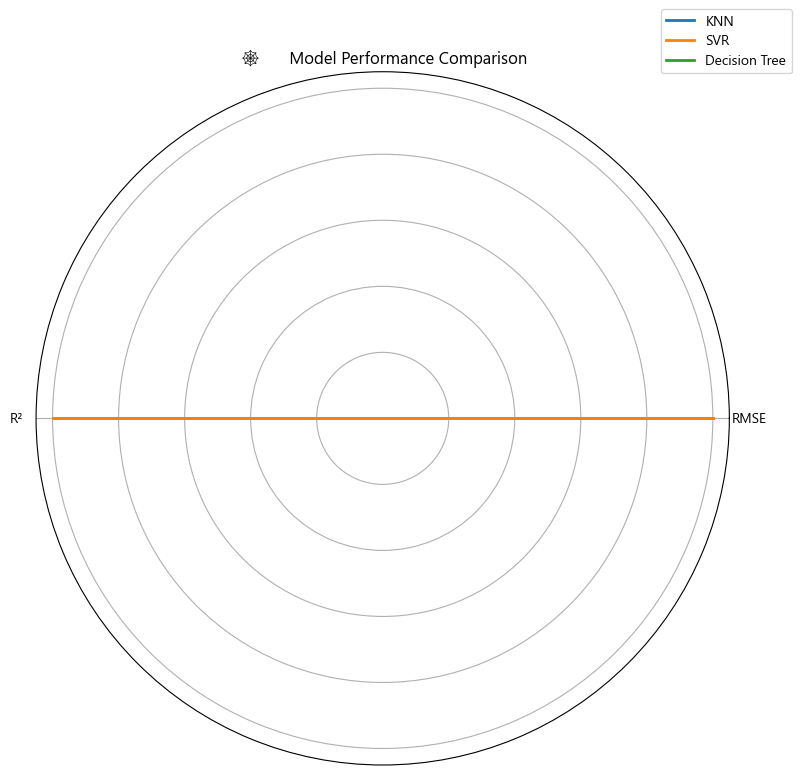

In [165]:
from math import pi
from sklearn.preprocessing import MinMaxScaler

# Normalize RMSE (lower is better, so we reverse it)
normalized = results_df.copy()
normalized['RMSE'] = 1 / (1 + normalized['RMSE'])  # Inverse RMSE to make higher = better
scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(normalized[['RMSE', 'R²']]), columns=['RMSE', 'R²'])
scaled['Model'] = results_df['Model']

# Radar chart setup
categories = list(scaled.columns[:-1])
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the circle

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for i, row in scaled.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row['Model'], linewidth=2)
    ax.fill(angles, values, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticklabels([])
plt.title('🕸️ Model Performance Comparison')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()
plt.show()


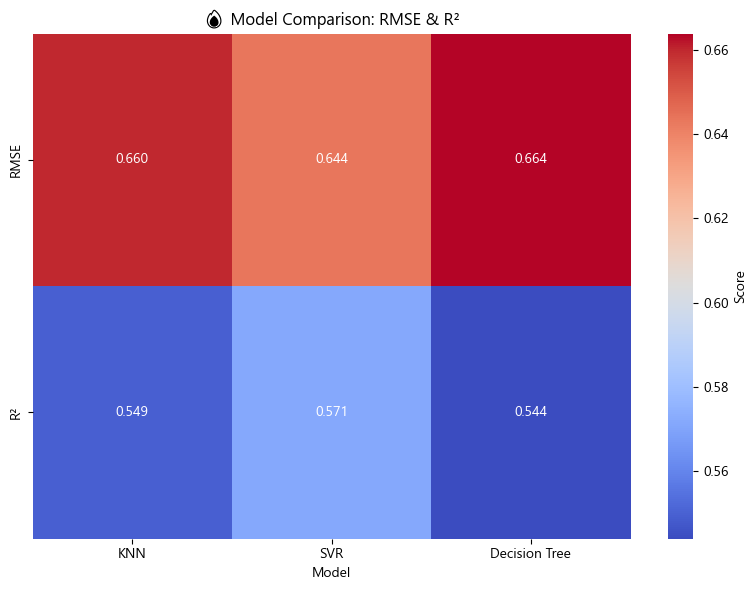

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame to hold the results
comparison_df = pd.DataFrame({
    'Model': ['KNN', 'SVR', 'Decision Tree'],
    'RMSE': [knn_rmse, svm_rmse, dt_rmse],
    'R²': [knn_r2, svm_r2, dt_r2]
})

# Set the Model column as index
comparison_df.set_index('Model', inplace=True)

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(comparison_df.T, annot=True, cmap='coolwarm', fmt='.3f', cbar_kws={'label': 'Score'})
plt.title('🔥 Model Comparison: RMSE & R²')
plt.tight_layout()
plt.show()


In [177]:
# Rank models based on RMSE (lowest) and R² (highest)
results_df['Rank'] = results_df['RMSE'].rank() + results_df['R²'].rank(ascending=False)
best_model = results_df.sort_values(by='Rank').iloc[0]
print(f"🎯 Best Model: {best_model['Model']} with Rank: {best_model['Rank']}")


🎯 Best Model: SVR with Rank: 2.0


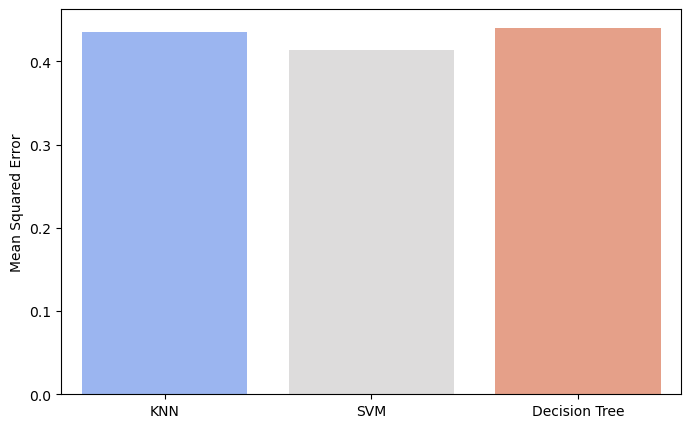

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
models = ['KNN', 'SVM','Decision Tree']
mse_values = [knn_mse, svm_mse,dt_mse]

sns.barplot(x=models, y=mse_values, hue=models, palette="coolwarm", legend=False)
plt.ylabel("Mean Squared Error")
plt.show()

In [179]:
models = {
    "KNN": knn_mse,
    "SVR": svm_mse,
    "Decision Tree": dt_mse
}

best_model = min(models, key=models.get)
print(f"\nBest performing model: {best_model} (Lowest MSE)")


Best performing model: SVR (Lowest MSE)
